# ch243 — Events

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. From Outcomes to Events

You rarely care about a specific outcome. You care about *classes* of outcomes: "did I roll an even number?", "did the model classify correctly?", "is the reading above a threshold?".

An **event** is a subset of the sample space Ω. Formally: E ⊆ Ω.

*(Subsets and set operations were introduced in ch011 — Sets and Basic Set Operations.)*

Examples for Ω = {1, 2, 3, 4, 5, 6}:

| Event | Subset |
|-------|--------|
| Roll an even number | {2, 4, 6} |
| Roll a number > 4 | {5, 6} |
| Roll a prime | {2, 3, 5} |
| Roll any number | Ω (the certain event) |
| Roll a 7 | ∅ (the impossible event) |

In [1]:
import numpy as np

Omega = {1, 2, 3, 4, 5, 6}

# Define events as sets
E_even = {x for x in Omega if x % 2 == 0}
E_gt4  = {x for x in Omega if x > 4}
E_prime = {x for x in Omega if x in {2, 3, 5}}

print(f"Ω = {sorted(Omega)}")
print(f"E_even  = {sorted(E_even)}")
print(f"E_gt4   = {sorted(E_gt4)}")
print(f"E_prime = {sorted(E_prime)}")

Ω = [1, 2, 3, 4, 5, 6]
E_even  = [2, 4, 6]
E_gt4   = [5, 6]
E_prime = [2, 3, 5]


## 2. Set Operations on Events

Because events are sets, all set operations apply — and each has a direct probabilistic interpretation:

| Set operation | Probabilistic meaning |
|---------------|----------------------|
| E ∪ F | E **or** F (at least one occurs) |
| E ∩ F | E **and** F (both occur) |
| Eᶜ = Ω \ E | E does **not** occur |
| E \ F | E occurs but F does **not** |

In [2]:
E = E_even
F = E_prime

E_union_F = E | F           # E or F
E_inter_F = E & F           # E and F
E_complement = Omega - E    # not E
E_minus_F = E - F           # E but not F

print(f"E (even) = {sorted(E)}")
print(f"F (prime) = {sorted(F)}")
print(f"E ∪ F = {sorted(E_union_F)}  (even OR prime)")
print(f"E ∩ F = {sorted(E_inter_F)}  (even AND prime — only 2)")
print(f"Eᶜ    = {sorted(E_complement)}  (not even = odd)")
print(f"E \ F  = {sorted(E_minus_F)}  (even but not prime)")

E (even) = [2, 4, 6]
F (prime) = [2, 3, 5]
E ∪ F = [2, 3, 4, 5, 6]  (even OR prime)
E ∩ F = [2]  (even AND prime — only 2)
Eᶜ    = [1, 3, 5]  (not even = odd)
E \ F  = [4, 6]  (even but not prime)


<>:14: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
C:\Users\user\AppData\Local\Temp\ipykernel_25344\1960121485.py:14: SyntaxWarning: invalid escape sequence '\ '
  print(f"E \ F  = {sorted(E_minus_F)}  (even but not prime)")


## 3. Mutually Exclusive Events

Two events are **mutually exclusive** (disjoint) if they cannot both occur:
$$E \cap F = \emptyset$$

For a single die roll, "roll a 1" and "roll a 6" are mutually exclusive. "Roll an even" and "roll a prime" are **not** (the outcome 2 is both).

In [3]:
def are_mutually_exclusive(E, F):
    return len(E & F) == 0

E_one = {1}
E_six = {6}

print(f"E_one ∩ E_six = {E_one & E_six} → mutually exclusive: {are_mutually_exclusive(E_one, E_six)}")
print(f"E_even ∩ E_prime = {E_even & E_prime} → mutually exclusive: {are_mutually_exclusive(E_even, E_prime)}")

E_one ∩ E_six = set() → mutually exclusive: True
E_even ∩ E_prime = {2} → mutually exclusive: False


## 4. Counting Events

For **finite uniform sample spaces**, the probability of an event is the count of favorable outcomes divided by the total:
$$P(E) = \frac{|E|}{|\Omega|}$$

This only holds when all outcomes are equally likely.

In [4]:
def uniform_prob(event, sample_space):
    """P(E) under uniform distribution."""
    return len(event) / len(sample_space)

print(f"P(even)  = {uniform_prob(E_even, Omega):.4f}")
print(f"P(prime) = {uniform_prob(E_prime, Omega):.4f}")
print(f"P(even ∪ prime) = {uniform_prob(E_even | E_prime, Omega):.4f}")
print(f"P(even ∩ prime) = {uniform_prob(E_even & E_prime, Omega):.4f}")

# Verify empirically
rng = np.random.default_rng(seed=0)
n = 100_000
rolls = rng.integers(1, 7, size=n)

p_even_empirical = np.mean(rolls % 2 == 0)
print(f"\nEmpirical P(even) over {n:,} rolls: {p_even_empirical:.4f}")

P(even)  = 0.5000
P(prime) = 0.5000
P(even ∪ prime) = 0.8333
P(even ∩ prime) = 0.1667

Empirical P(even) over 100,000 rolls: 0.4976


## 5. Compound Events: Two-Dice Example

With two dice, the sample space has 36 outcomes. Compound events involve both dice.

|Ω| = 36
P(sum=7) = 6/36 = 0.1667
  Outcomes: [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
P(sum≥10) = 6/36 = 0.1667


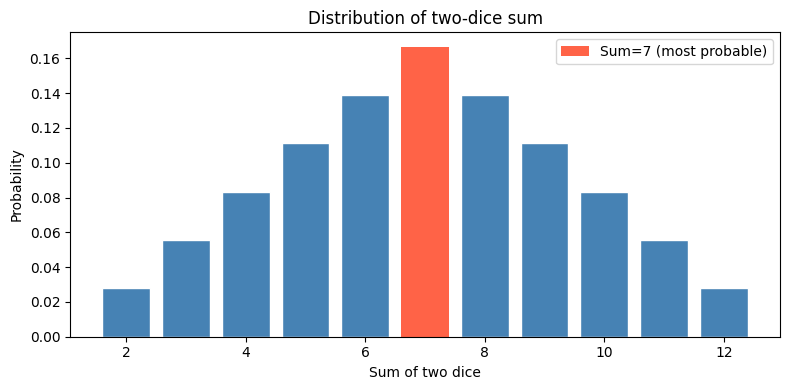

In [5]:
import matplotlib.pyplot as plt
from itertools import product

Omega2 = list(product(range(1, 7), range(1, 7)))

# Event: sum equals 7
E_sum7 = [(d1, d2) for d1, d2 in Omega2 if d1 + d2 == 7]

# Event: sum >= 10
E_sum_ge10 = [(d1, d2) for d1, d2 in Omega2 if d1 + d2 >= 10]

print(f"|Ω| = {len(Omega2)}")
print(f"P(sum=7) = {len(E_sum7)}/{len(Omega2)} = {len(E_sum7)/len(Omega2):.4f}")
print(f"  Outcomes: {E_sum7}")
print(f"P(sum≥10) = {len(E_sum_ge10)}/{len(Omega2)} = {len(E_sum_ge10)/len(Omega2):.4f}")

# Visualize distribution of sums
sums = [d1 + d2 for d1, d2 in Omega2]
sum_values, sum_counts = np.unique(sums, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sum_values, sum_counts / len(Omega2), color='steelblue', edgecolor='white')
ax.bar(7, 6 / 36, color='tomato', label='Sum=7 (most probable)')
ax.set_xlabel('Sum of two dice')
ax.set_ylabel('Probability')
ax.set_title('Distribution of two-dice sum')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary

- An event is any subset of the sample space.
- Set operations (union, intersection, complement) map directly to probabilistic concepts (or, and, not).
- Mutually exclusive events have no outcomes in common; their probabilities add directly.
- Under uniform distributions, P(E) = |E| / |Ω|.

---

## 7. Forward References

The rules for combining probabilities of events — including how union and intersection interact — are formalized in ch244 (Probability Rules). The special case of events conditioned on other events appears in ch245 (Conditional Probability), which is the gateway to Bayesian reasoning in ch246.